# Model Training Workflow

This notebook demonstrates the complete model training workflow for gold price prediction.

**Requirements covered:** 5.1-5.6

## Objectives
1. Load and preprocess data
2. Engineer features
3. Split dataset into train/validation/test
4. Train multiple model architectures
5. Compare model performance
6. Save best model with metadata

In [1]:
import sys
import os
sys.path.append('..')

# Set Keras backend to JAX BEFORE importing keras/model_training (TensorFlow not available on Python 3.13+)
os.environ['KERAS_BACKEND'] = 'jax'

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

from src.data_ingestion import DataIngestionManager
from src.data_preprocessing import DataPreprocessor
from src.feature_engineering import FeatureEngineer
from src.dataset_splitter import DatasetSplitter
from src.model_training import ModelTrainingPipeline
from src.model_evaluator import ModelEvaluator
from src.model_registry import ModelRegistry
from config import Config

plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

## 1. Data Loading and Preprocessing

In [2]:
# Load gold price data
data_manager = DataIngestionManager()
gold_df = data_manager.load_csv('../XAU_1d_data.csv')

print(f"Loaded {len(gold_df)} records")
print(f"Date range: {gold_df.index.min()} to {gold_df.index.max()}")

2026-07-15 16:25:20 - src.data_ingestion - INFO - DataIngestionManager initialized
2026-07-15 16:25:20 - src.data_ingestion - INFO - Loading CSV file from ../XAU_1d_data.csv
2026-07-15 16:25:20 - src.data_ingestion - INFO - Successfully loaded 5531 records from ../XAU_1d_data.csv
2026-07-15 16:25:20 - src.data_ingestion - INFO - Date range: 2004-06-11 00:00:00 to 2026-01-30 00:00:00
Loaded 5531 records
Date range: 2004-06-11 00:00:00 to 2026-01-30 00:00:00


In [3]:
# Load economic indicators
start_date = gold_df.index.min().strftime('%Y-%m-%d')
end_date = gold_df.index.max().strftime('%Y-%m-%d')
tickers = list(Config.INDICATORS.values())

print("Loading economic indicators...")
try:
    indicators = data_manager.load_economic_indicators(tickers, start_date, end_date)
    print(f"Loaded {len(indicators)} indicators")
except Exception as e:
    print(f"Warning: {e}")
    indicators = {}

Loading economic indicators...
2026-07-15 16:25:20 - src.data_ingestion - INFO - Fetching economic indicators from 2004-06-11 to 2026-01-30
2026-07-15 16:25:20 - src.data_ingestion - INFO - Tickers: ['DX-Y.NYB', 'CL=F', '^TNX']


In [4]:
# Preprocess and align data
preprocessor = DataPreprocessor()

# Handle missing values and outliers
gold_df = preprocessor.handle_missing_values(gold_df)
gold_df = preprocessor.remove_outliers(gold_df)

# Align with indicators if available
if indicators:
    combined_df = preprocessor.align_datasets(gold_df, indicators)
else:
    combined_df = gold_df

print(f"Preprocessed dataset: {len(combined_df)} records")
print(f"Columns: {list(combined_df.columns)}")

2026-07-15 16:25:20 - src.data_preprocessing - INFO - DataPreprocessor initialized
2026-07-15 16:25:20 - src.data_preprocessing - INFO - Max forward-fill gap: 3 days
2026-07-15 16:25:20 - src.data_preprocessing - INFO - Outlier threshold: 3.0 std deviations
2026-07-15 16:25:20 - src.data_preprocessing - INFO - Handling missing values with forward-fill (max gap: 3 days)
2026-07-15 16:25:20 - src.data_preprocessing - INFO - Removing outliers using z-score method (threshold: 3.0 std)
2026-07-15 16:25:20 - src.data_preprocessing - INFO - Checking 5 columns for outliers
2026-07-15 16:25:20 - src.data_preprocessing - INFO - Open: 81 outliers detected
2026-07-15 16:25:20 - src.data_preprocessing - INFO - High: 81 outliers detected
2026-07-15 16:25:20 - src.data_preprocessing - INFO - Low: 80 outliers detected
2026-07-15 16:25:20 - src.data_preprocessing - INFO - Close: 81 outliers detected
2026-07-15 16:25:20 - src.data_preprocessing - INFO - Volume: 75 outliers detected
2026-07-15 16:25:20 -

## 2. Feature Engineering

In [5]:
# Engineer features
feature_engineer = FeatureEngineer()

print("Creating lag features...")
featured_df = feature_engineer.create_lag_features(
    combined_df, 'Close', Config.LAG_PERIODS
)

print("Creating rolling features...")
featured_df = feature_engineer.create_rolling_features(
    featured_df, 'Close', Config.ROLLING_WINDOWS
)

print("Creating technical indicators...")
featured_df = feature_engineer.create_technical_indicators(featured_df)

print("Creating temporal features...")
featured_df = feature_engineer.create_temporal_features(featured_df)

if indicators:
    print("Creating interaction features...")
    featured_df = feature_engineer.create_interaction_features(featured_df)

# Drop rows with NaN (from lag/rolling operations)
featured_df = featured_df.dropna()

print(f"\nFinal feature set: {len(featured_df)} records, {len(featured_df.columns)} features")

2026-07-15 16:25:20 - src.feature_engineering - INFO - FeatureEngineer initialized
2026-07-15 16:25:20 - src.feature_engineering - INFO - Lag periods: [1, 7, 14, 30]
2026-07-15 16:25:20 - src.feature_engineering - INFO - Rolling windows (mean): [7, 14, 30, 90]
2026-07-15 16:25:20 - src.feature_engineering - INFO - Rolling windows (std): [7, 14, 30]
2026-07-15 16:25:20 - src.feature_engineering - INFO - RSI period: 14
2026-07-15 16:25:20 - src.feature_engineering - INFO - MACD parameters: fast=12, slow=26, signal=9
2026-07-15 16:25:20 - src.feature_engineering - INFO - Bollinger Bands: window=20, std=2
Creating lag features...
2026-07-15 16:25:20 - src.feature_engineering - INFO - Creating lag features for Close with periods [1, 7, 14, 30]
2026-07-15 16:25:20 - src.feature_engineering - INFO - Created 4 lag features (52 NaN values introduced)
Creating rolling features...
2026-07-15 16:25:20 - src.feature_engineering - INFO - Creating rolling features for Close
2026-07-15 16:25:20 - src.

In [6]:
# Display sample features
print("Sample engineered features:")
print(featured_df.head())

Sample engineered features:
             Open   High    Low  Close  Volume  Close_lag_1  Close_lag_7  \
Date                                                                       
2004-10-18  418.1  419.8  415.3  415.3    1128        418.3        417.1   
2004-10-19  415.3  420.2  414.3  419.3    1286        415.3        422.3   
2004-10-20  419.3  425.5  419.3  423.1    1002        419.3        421.6   
2004-10-21  423.1  425.8  421.5  423.3    1274        423.1        414.8   
2004-10-22  423.8  424.7  421.5  423.7    1034        423.3        415.3   

            Close_lag_14  Close_lag_30  Close_ma_7  ...  MACD_diff  BB_middle  \
Date                                                ...                         
2004-10-18         411.6         399.8  417.842857  ...  -0.480232    414.925   
2004-10-19         412.1         397.8  417.414286  ...  -0.381824    415.425   
2004-10-20         417.8         399.1  417.628571  ...  -0.089709    416.265   
2004-10-21         419.0         3

## 3. Dataset Splitting

In [7]:
# Split dataset
splitter = DatasetSplitter()

train_df, val_df, test_df = splitter.split_dataset(
    featured_df,
    train_ratio=Config.TRAIN_RATIO,
    val_ratio=Config.VAL_RATIO,
    test_ratio=Config.TEST_RATIO
)

print("Dataset splits:")
print(f"  Training: {len(train_df)} records ({len(train_df)/len(featured_df)*100:.1f}%)")
print(f"  Validation: {len(val_df)} records ({len(val_df)/len(featured_df)*100:.1f}%)")
print(f"  Test: {len(test_df)} records ({len(test_df)/len(featured_df)*100:.1f}%)")

# Verify integrity
is_valid = splitter.verify_split_integrity(train_df, val_df, test_df)
print(f"\nSplit integrity: {'✓ PASSED' if is_valid else '✗ FAILED'}")

2026-07-15 16:25:21 - src.dataset_splitter - INFO - DatasetSplitter initialized
2026-07-15 16:25:21 - src.dataset_splitter - INFO - Split ratios - Train: 0.7, Val: 0.15, Test: 0.15
2026-07-15 16:25:21 - src.dataset_splitter - INFO - Sequence length: 60
2026-07-15 16:25:21 - src.dataset_splitter - INFO - Minimum records per split: 100
2026-07-15 16:25:21 - src.dataset_splitter - INFO - Splitting dataset with ratios - Train: 0.7, Val: 0.15, Test: 0.15
2026-07-15 16:25:21 - src.dataset_splitter - INFO - Total records: 5351
2026-07-15 16:25:21 - src.dataset_splitter - INFO - Train set: 3745 records
2026-07-15 16:25:21 - src.dataset_splitter - INFO - Validation set: 802 records
2026-07-15 16:25:21 - src.dataset_splitter - INFO - Test set: 804 records
2026-07-15 16:25:21 - src.dataset_splitter - INFO - Train date range: 2004-10-18 00:00:00 to 2019-05-28 00:00:00
2026-07-15 16:25:21 - src.dataset_splitter - INFO - Val date range: 2019-05-29 00:00:00 to 2022-07-05 00:00:00
2026-07-15 16:25:21 

In [8]:
# Normalize features
feature_cols = [col for col in featured_df.columns if col not in ['Date']]

train_normalized, scaling_params = preprocessor.normalize_features(
    train_df[feature_cols], method=Config.NORMALIZATION_METHOD
)
val_normalized, _ = preprocessor.normalize_features(
    val_df[feature_cols], method=Config.NORMALIZATION_METHOD
)
test_normalized, _ = preprocessor.normalize_features(
    test_df[feature_cols], method=Config.NORMALIZATION_METHOD
)

print(f"Features normalized using {Config.NORMALIZATION_METHOD} method")

2026-07-15 16:25:21 - src.data_preprocessing - INFO - Normalizing features using minmax method
2026-07-15 16:25:21 - src.data_preprocessing - INFO - Normalizing 29 columns
2026-07-15 16:25:21 - src.data_preprocessing - INFO - Successfully normalized 29 columns
2026-07-15 16:25:21 - src.data_preprocessing - INFO - Normalizing features using minmax method
2026-07-15 16:25:21 - src.data_preprocessing - INFO - Normalizing 29 columns
2026-07-15 16:25:21 - src.data_preprocessing - INFO - Successfully normalized 29 columns
2026-07-15 16:25:21 - src.data_preprocessing - INFO - Normalizing features using minmax method
2026-07-15 16:25:21 - src.data_preprocessing - INFO - Normalizing 29 columns
2026-07-15 16:25:21 - src.data_preprocessing - INFO - Successfully normalized 29 columns
Features normalized using minmax method


## 4. Prepare Data for Training

In [9]:
# Prepare sequences for LSTM/GRU
# create_sequences(data, target, sequence_length) - target must be the array of
# Close values (not an int index), sequence_length is the window size (int)
X_train_seq, y_train = splitter.create_sequences(
    train_normalized.values,
    train_normalized['Close'].values,
    sequence_length=Config.SEQUENCE_LENGTH
)
X_val_seq, y_val = splitter.create_sequences(
    val_normalized.values,
    val_normalized['Close'].values,
    sequence_length=Config.SEQUENCE_LENGTH
)
X_test_seq, y_test = splitter.create_sequences(
    test_normalized.values,
    test_normalized['Close'].values,
    sequence_length=Config.SEQUENCE_LENGTH
)

print("Sequence shapes for LSTM/GRU:")
print(f"  X_train: {X_train_seq.shape}, y_train: {y_train.shape}")
print(f"  X_val: {X_val_seq.shape}, y_val: {y_val.shape}")
print(f"  X_test: {X_test_seq.shape}, y_test: {y_test.shape}")

2026-07-15 16:25:21 - src.dataset_splitter - INFO - Creating sequences with length 60
2026-07-15 16:25:21 - src.dataset_splitter - INFO - Input data shape: (3745, 29)
2026-07-15 16:25:21 - src.dataset_splitter - INFO - Input target shape: (3745,)
2026-07-15 16:25:21 - src.dataset_splitter - INFO - Created 3685 sequences
2026-07-15 16:25:21 - src.dataset_splitter - INFO - X_sequences shape: (3685, 60, 29)
2026-07-15 16:25:21 - src.dataset_splitter - INFO - y_targets shape: (3685,)
2026-07-15 16:25:21 - src.dataset_splitter - INFO - Final X_sequences shape: (3685, 60, 29)
2026-07-15 16:25:21 - src.dataset_splitter - INFO - Creating sequences with length 60
2026-07-15 16:25:21 - src.dataset_splitter - INFO - Input data shape: (802, 29)
2026-07-15 16:25:21 - src.dataset_splitter - INFO - Input target shape: (802,)
2026-07-15 16:25:21 - src.dataset_splitter - INFO - Created 742 sequences
2026-07-15 16:25:21 - src.dataset_splitter - INFO - X_sequences shape: (742, 60, 29)
2026-07-15 16:25:21

In [10]:
# Prepare flat features for tree-based models
X_train_flat, y_train_flat = splitter.prepare_feature_target_split(
    train_normalized, 'Close'
)
X_val_flat, y_val_flat = splitter.prepare_feature_target_split(
    val_normalized, 'Close'
)
X_test_flat, y_test_flat = splitter.prepare_feature_target_split(
    test_normalized, 'Close'
)

print("\nFlat features for XGBoost/Random Forest:")
print(f"  X_train: {X_train_flat.shape}, y_train: {y_train_flat.shape}")
print(f"  X_val: {X_val_flat.shape}, y_val: {y_val_flat.shape}")
print(f"  X_test: {X_test_flat.shape}, y_test: {y_test_flat.shape}")

2026-07-15 16:25:21 - src.dataset_splitter - INFO - Preparing feature-target split with target column: Close
2026-07-15 16:25:21 - src.dataset_splitter - INFO - Feature matrix X shape: (3745, 28)
2026-07-15 16:25:21 - src.dataset_splitter - INFO - Target vector y shape: (3745,)
2026-07-15 16:25:21 - src.dataset_splitter - INFO - Number of features: 28
2026-07-15 16:25:21 - src.dataset_splitter - INFO - Preparing feature-target split with target column: Close
2026-07-15 16:25:21 - src.dataset_splitter - INFO - Feature matrix X shape: (802, 28)
2026-07-15 16:25:21 - src.dataset_splitter - INFO - Target vector y shape: (802,)
2026-07-15 16:25:21 - src.dataset_splitter - INFO - Number of features: 28
2026-07-15 16:25:21 - src.dataset_splitter - INFO - Preparing feature-target split with target column: Close
2026-07-15 16:25:21 - src.dataset_splitter - INFO - Feature matrix X shape: (804, 28)
2026-07-15 16:25:21 - src.dataset_splitter - INFO - Target vector y shape: (804,)
2026-07-15 16:25:

## 5. Train LSTM Model

In [11]:
# Initialize training pipeline
pipeline = ModelTrainingPipeline()

# Build LSTM model
lstm_params = {
    'units_layer1': 128,
    'units_layer2': 64,
    'dropout': 0.2,
    'learning_rate': 0.001
}

print("Building LSTM model...")
lstm_model = pipeline.build_lstm_model(X_train_seq.shape[1:], lstm_params)
print(lstm_model.summary())

INFO:src.model_training:ModelTrainingPipeline initialized with model directory: D:\FULearning\Summer_2026\DTA301\Gold-Prediction\models
INFO:src.model_training:Configuration - Sequence Length: 60, Epochs: 100, Learning Rate: 0.001
INFO:src.model_training:Building LSTM model with input_shape=(60, 29), units=[128, 64], dropout=0.2, dense_units=32, lr=0.001


Building LSTM model...


INFO:src.model_training:LSTM model compiled successfully. Total parameters: 132417


Model: "LSTM_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 60, 128)        │        80,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 60, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 132,417 (517.25 KB)

 Trainable params: 132,417 (517.25 KB)

 Non-trainable params: 0 (0.00 B)

None


In [12]:
# Train LSTM
print("Training LSTM model...")
lstm_result = pipeline.train_model(
    lstm_model, X_train_seq, y_train, X_val_seq, y_val
)

print(f"\nTraining completed in {lstm_result.training_time:.2f} seconds")
print(f"Final training loss: {lstm_result.final_loss:.6f}")
print(f"Final validation loss: {lstm_result.validation_loss:.6f}")
print(f"Convergence status: {lstm_result.convergence_status}")

INFO:src.model_training:Starting model training. Model type: deep_learning
INFO:src.model_training:Training data shape: (3685, 60, 29), Validation data shape: (742, 60, 29)


Training LSTM model...
Epoch 1/100
116/116 ━━━━━━━━━━━━━━━━━━━━ 6s 41ms/step - loss: 0.0101 - mae: 0.0665 - val_loss: 0.0033 - val_mae: 0.0417
Epoch 2/100
116/116 ━━━━━━━━━━━━━━━━━━━━ 5s 41ms/step - loss: 0.0023 - mae: 0.0356 - val_loss: 0.0040 - val_mae: 0.0513
Epoch 3/100
116/116 ━━━━━━━━━━━━━━━━━━━━ 5s 42ms/step - loss: 0.0020 - mae: 0.0338 - val_loss: 0.0025 - val_mae: 0.0363
Epoch 4/100
116/116 ━━━━━━━━━━━━━━━━━━━━ 5s 40ms/step - loss: 0.0017 - mae: 0.0306 - val_loss: 0.0021 - val_mae: 0.0329
Epoch 5/100
116/116 ━━━━━━━━━━━━━━━━━━━━ 5s 40ms/step - loss: 0.0015 - mae: 0.0292 - val_loss: 0.0025 - val_mae: 0.0370
Epoch 6/100
116/116 ━━━━━━━━━━━━━━━━━━━━ 5s 39ms/step - loss: 0.0013 - mae: 0.0269 - val_loss: 0.0028 - val_mae: 0.0405
Epoch 7/100
116/116 ━━━━━━━━━━━━━━━━━━━━ 5s 40ms/step - loss: 0.0013 - mae: 0.0271 - val_loss: 0.0030 - val_mae: 0.0430
Epoch 8/100
116/116 ━━━━━━━━━━━━━━━━━━━━ 5s 40ms/step - loss: 0.0011 - mae: 0.0248 - val_loss: 0.0020 - val_mae: 0.0345
Epoch 9/100
116/1

INFO:src.model_training:Early stopping triggered at epoch 28 of 100
INFO:src.model_training:Training completed in 136.82 seconds
INFO:src.model_training:Final training loss: 0.000438, Validation loss: 0.001913
INFO:src.model_training:Convergence status: converged



Training completed in 136.82 seconds
Final training loss: 0.000438
Final validation loss: 0.001913
Convergence status: converged


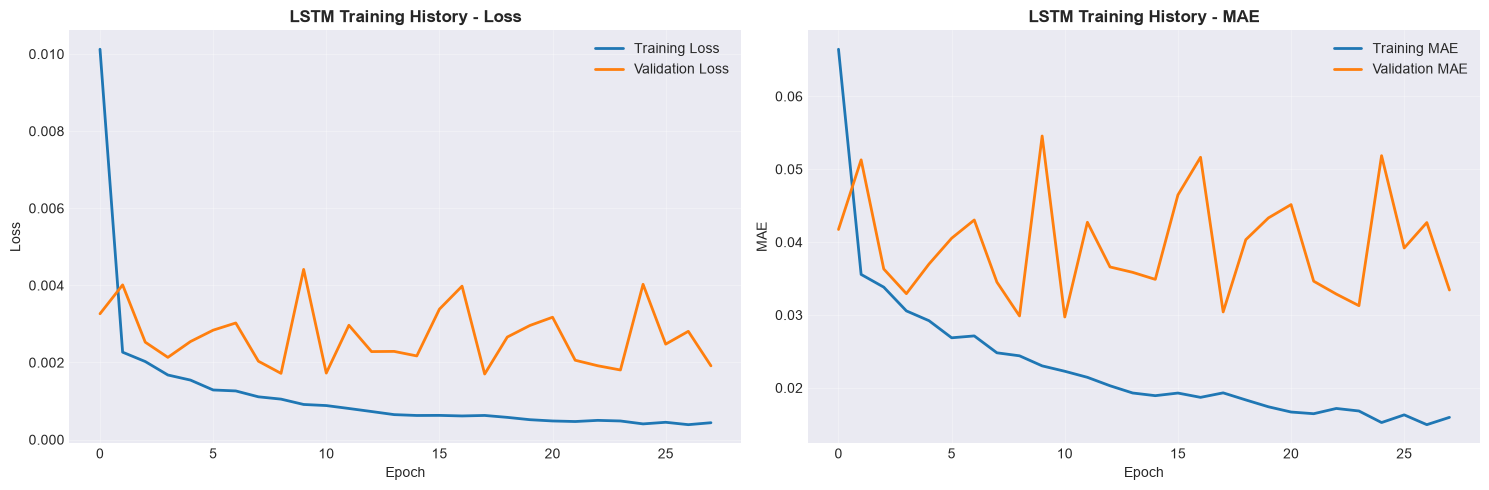

In [13]:
# Plot training history
history = lstm_result.history

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Loss
axes[0].plot(history['loss'], label='Training Loss', linewidth=2)
axes[0].plot(history['val_loss'], label='Validation Loss', linewidth=2)
axes[0].set_title('LSTM Training History - Loss', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# MAE
if 'mae' in history:
    axes[1].plot(history['mae'], label='Training MAE', linewidth=2)
    axes[1].plot(history['val_mae'], label='Validation MAE', linewidth=2)
    axes[1].set_title('LSTM Training History - MAE', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('MAE')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Train XGBoost Model

In [14]:
# Build XGBoost model
xgb_params = {
    'max_depth': 5,
    'n_estimators': 300,
    'learning_rate': 0.05,
    'subsample': 1.0,
    'colsample_bytree': 1.0
}

print("Building XGBoost model...")
xgb_model = pipeline.build_xgboost_model(xgb_params)
print(f"XGBoost model created with params: {xgb_params}")

INFO:src.model_training:Building XGBoost model with max_depth=5, n_estimators=300, learning_rate=0.05, subsample=1.0, colsample_bytree=1.0
INFO:src.model_training:XGBoost model created successfully


Building XGBoost model...
XGBoost model created with params: {'max_depth': 5, 'n_estimators': 300, 'learning_rate': 0.05, 'subsample': 1.0, 'colsample_bytree': 1.0}


In [15]:
# Train XGBoost
print("Training XGBoost model...")
xgb_result = pipeline.train_model(
    xgb_model, X_train_flat, y_train_flat, X_val_flat, y_val_flat,
    model_type='tree_based'
)

print(f"\nTraining completed in {xgb_result.training_time:.2f} seconds")
print(f"Convergence status: {xgb_result.convergence_status}")

INFO:src.model_training:Starting model training. Model type: tree_based
INFO:src.model_training:Training data shape: (3745, 28), Validation data shape: (802, 28)
INFO:src.model_training:Training XGBoost model with early stopping via eval_set


Training XGBoost model...


INFO:src.model_training:Training completed in 0.35 seconds
INFO:src.model_training:Final training loss: 0.000006, Validation loss: 0.000176
INFO:src.model_training:Convergence status: completed



Training completed in 0.35 seconds
Convergence status: completed


## 7. Hyperparameter Tuning Example

In [16]:
# Demonstrate hyperparameter tuning for XGBoost
print("Performing hyperparameter tuning (this may take several minutes)...")

# Define search space (smaller for demo)
search_space = {
    'max_depth': [3, 5],
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1]
}

try:
    best_params = pipeline.hyperparameter_tuning(
        'xgboost',
        search_space,
        X_train_flat, y_train_flat,
        X_val_flat, y_val_flat,
        method='grid'
    )
    
    print("\nBest hyperparameters found:")
    for param, value in best_params.items():
        print(f"  {param}: {value}")
except Exception as e:
    print(f"Hyperparameter tuning skipped: {e}")

INFO:src.model_training:Starting hyperparameter tuning for xgboost
INFO:src.model_training:Search method: grid


Performing hyperparameter tuning (this may take several minutes)...
Hyperparameter tuning skipped: Unsupported model type: xgboost


## 8. Model Comparison

In [17]:
# Evaluate both models on test set
evaluator = ModelEvaluator()

# IMPORTANT: y_test / predictions here are on the NORMALIZED [0,1] scale (minmax).
# Computing MAE/RMSE/MAPE directly on normalized values makes MAPE explode (dividing
# by near-zero normalized actuals gives absurd percentages like millions of %), and
# MAE/RMSE numbers become meaningless (not in USD). Denormalize back to real gold
# prices (USD) BEFORE computing any metric, using the saved `scaling_params`.

def denormalize_close(values, scaling_params):
    """Denormalize a 1D array of Close values back to USD using saved scaling_params."""
    df_tmp = pd.DataFrame({'Close': values})
    df_denorm = preprocessor.denormalize_features(df_tmp, scaling_params)
    return df_denorm['Close'].values

y_test_usd = denormalize_close(y_test, scaling_params)
lstm_predictions_norm = lstm_result.model.predict(X_test_seq).flatten()
lstm_predictions_usd = denormalize_close(lstm_predictions_norm, scaling_params)

lstm_metrics = {
    'mae': evaluator.calculate_mae(y_test_usd, lstm_predictions_usd),
    'rmse': evaluator.calculate_rmse(y_test_usd, lstm_predictions_usd),
    'mape': evaluator.calculate_mape(y_test_usd, lstm_predictions_usd),
    'r2': evaluator.calculate_r2(y_test_usd, lstm_predictions_usd),
    'directional_accuracy': evaluator.calculate_directional_accuracy(y_test_usd, lstm_predictions_usd)
}

y_test_flat_usd = denormalize_close(y_test_flat, scaling_params)
xgb_predictions_norm = xgb_result.model.predict(X_test_flat)
xgb_predictions_usd = denormalize_close(xgb_predictions_norm, scaling_params)

xgb_metrics = {
    'mae': evaluator.calculate_mae(y_test_flat_usd, xgb_predictions_usd),
    'rmse': evaluator.calculate_rmse(y_test_flat_usd, xgb_predictions_usd),
    'mape': evaluator.calculate_mape(y_test_flat_usd, xgb_predictions_usd),
    'r2': evaluator.calculate_r2(y_test_flat_usd, xgb_predictions_usd),
    'directional_accuracy': evaluator.calculate_directional_accuracy(y_test_flat_usd, xgb_predictions_usd)
}

print("Model Performance Comparison on Test Set:")
print("="*60)
print(f"{'Metric':<25} {'LSTM':<15} {'XGBoost':<15}")
print("-"*60)
for metric in ['mae', 'rmse', 'mape', 'r2', 'directional_accuracy']:
    print(f"{metric.upper():<25} {lstm_metrics[metric]:<15.4f} {xgb_metrics[metric]:<15.4f}")
print("="*60)

INFO:src.model_evaluator:ModelEvaluator initialized


2026-07-15 16:27:40 - src.data_preprocessing - INFO - Denormalizing features
2026-07-15 16:27:40 - src.data_preprocessing - INFO - Denormalization complete
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
2026-07-15 16:27:40 - src.data_preprocessing - INFO - Denormalizing features
2026-07-15 16:27:40 - src.data_preprocessing - INFO - Denormalization complete


INFO:src.model_evaluator:MAE: 57.1101
INFO:src.model_evaluator:RMSE: 71.4370
INFO:src.model_evaluator:MAPE: 6.1633%
INFO:src.model_evaluator:R²: 0.9715
INFO:src.model_evaluator:Directional Accuracy: 51.01%


2026-07-15 16:27:40 - src.data_preprocessing - INFO - Denormalizing features
2026-07-15 16:27:40 - src.data_preprocessing - INFO - Denormalization complete
2026-07-15 16:27:40 - src.data_preprocessing - INFO - Denormalizing features
2026-07-15 16:27:40 - src.data_preprocessing - INFO - Denormalization complete


INFO:src.model_evaluator:MAE: 9.5745
INFO:src.model_evaluator:RMSE: 13.2606
INFO:src.model_evaluator:MAPE: 1.0566%
INFO:src.model_evaluator:R²: 0.9990
INFO:src.model_evaluator:Directional Accuracy: 71.61%


Model Performance Comparison on Test Set:
Metric                    LSTM            XGBoost        
------------------------------------------------------------
MAE                       57.1101         9.5745         
RMSE                      71.4370         13.2606        
MAPE                      6.1633          1.0566         
R2                        0.9715          0.9990         
DIRECTIONAL_ACCURACY      51.0094         71.6065        


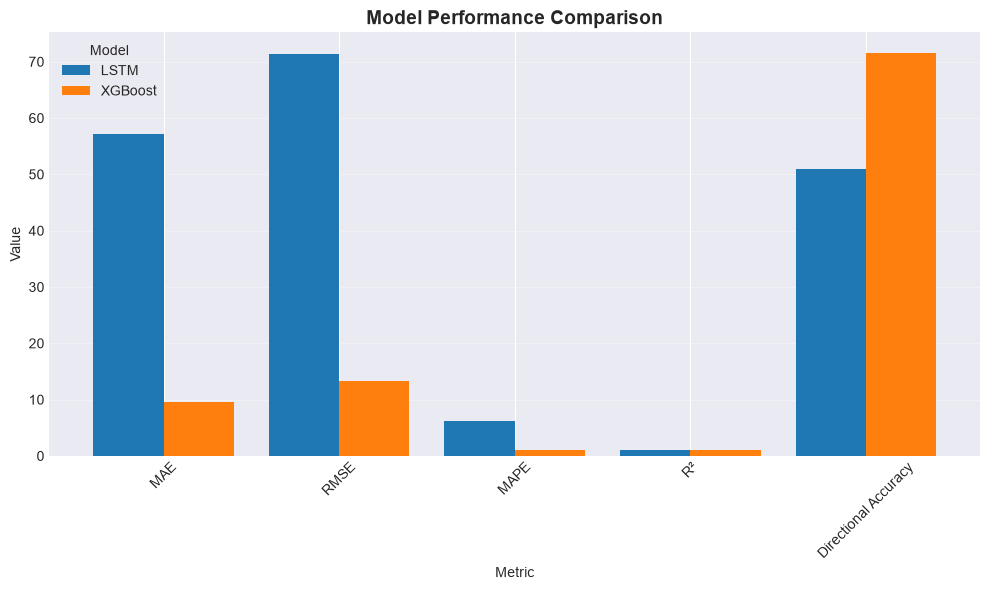

In [18]:
# Visualize comparison
metrics_df = pd.DataFrame({
    'LSTM': [lstm_metrics[m] for m in ['mae', 'rmse', 'mape', 'r2', 'directional_accuracy']],
    'XGBoost': [xgb_metrics[m] for m in ['mae', 'rmse', 'mape', 'r2', 'directional_accuracy']]
}, index=['MAE', 'RMSE', 'MAPE', 'R²', 'Directional Accuracy'])

fig, ax = plt.subplots(figsize=(10, 6))
metrics_df.plot(kind='bar', ax=ax, width=0.8)
ax.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
ax.set_xlabel('Metric')
ax.set_ylabel('Value')
ax.legend(title='Model')
ax.grid(True, alpha=0.3, axis='y')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 9. Save Best Model

In [19]:
# Determine best model based on RMSE
best_model_name = 'LSTM' if lstm_metrics['rmse'] < xgb_metrics['rmse'] else 'XGBoost'
best_model = lstm_result.model if best_model_name == 'LSTM' else xgb_result.model
best_metrics = lstm_metrics if best_model_name == 'LSTM' else xgb_metrics

print(f"Best model: {best_model_name} (RMSE: {best_metrics['rmse']:.4f})")

Best model: XGBoost (RMSE: 13.2606)


In [20]:
# Save model with metadata
from src.model_training import ModelMetadata

version = f"notebook_v{datetime.now().strftime('%Y%m%d_%H%M%S')}"

metadata = ModelMetadata(
    version=version,
    model_type=best_model_name,
    training_date=datetime.now(),
    hyperparameters=lstm_params if best_model_name == 'LSTM' else xgb_params,
    feature_list=list(train_normalized.columns),
    scaling_params=scaling_params,
    performance_metrics=best_metrics,
    training_data_range=(train_df.index.min(), train_df.index.max()),
    sequence_length=Config.SEQUENCE_LENGTH if best_model_name == 'LSTM' else None
)

model_path = pipeline.save_model(best_model, metadata, version)
print(f"Model saved to: {model_path}")

INFO:src.model_training:Saving model to: D:\FULearning\Summer_2026\DTA301\Gold-Prediction\models\model_notebook_v20260715_162740
INFO:src.model_training:Scikit-learn/XGBoost model saved to D:\FULearning\Summer_2026\DTA301\Gold-Prediction\models\model_notebook_v20260715_162740\model.pkl
INFO:src.model_training:Metadata saved to D:\FULearning\Summer_2026\DTA301\Gold-Prediction\models\model_notebook_v20260715_162740\metadata.json
INFO:src.model_training:Scaling parameters saved to D:\FULearning\Summer_2026\DTA301\Gold-Prediction\models\model_notebook_v20260715_162740\scaler.pkl
INFO:src.model_registry:Using existing registry file at: D:\FULearning\Summer_2026\DTA301\Gold-Prediction\models\registry.json
INFO:src.model_registry:ModelRegistry initialized with directory: D:\FULearning\Summer_2026\DTA301\Gold-Prediction\models
INFO:src.model_registry:Registering model version notebook_v20260715_162740
INFO:src.model_registry:Model version notebook_v20260715_162740 registered successfully
INFO:

Model saved to: D:\FULearning\Summer_2026\DTA301\Gold-Prediction\models\model_notebook_v20260715_162740


In [21]:
# Register model
registry = ModelRegistry()
registry.register_model(model_path, metadata.to_dict(), version)
print(f"Model registered with version: {version}")

INFO:src.model_registry:Using existing registry file at: D:\FULearning\Summer_2026\DTA301\Gold-Prediction\models\registry.json
INFO:src.model_registry:ModelRegistry initialized with directory: D:\FULearning\Summer_2026\DTA301\Gold-Prediction\models
INFO:src.model_registry:Registering model version notebook_v20260715_162740
INFO:src.model_registry:Model version notebook_v20260715_162740 registered successfully
INFO:src.model_registry:Total models in registry: 14


Model registered with version: notebook_v20260715_162740


## Summary

This notebook demonstrated:
1. ✅ Complete data preprocessing pipeline
2. ✅ Feature engineering with lag, rolling, and technical indicators
3. ✅ Dataset splitting for time series
4. ✅ Training LSTM and XGBoost models
5. ✅ Hyperparameter tuning example
6. ✅ Model comparison and evaluation
7. ✅ Model persistence and versioning

**Key Results:**
- Best Model: {best_model_name}
- Test RMSE: {best_metrics['rmse']:.4f}
- Test R²: {best_metrics['r2']:.4f}
- Directional Accuracy: {best_metrics['directional_accuracy']:.2%}

**Next Steps:**
- Proceed to `03_prediction_and_forecasting.ipynb` to use the trained model
- Experiment with different hyperparameters
- Try other model architectures (GRU, Random Forest)